# Proyecto de ejemplo: pronóstico de la demanda eléctrica del mercado de comercialización del Valle del Cauca (2020–2025)

Cuaderno de un trabajo de grado de especialización en analítica de datos, compartido con autorización de sus autores con fines educativos. Se retiraron los nombres y los datos personales.

Consulta el [README del proyecto](README.md) para ver el orden de los cuadernos, las fuentes de datos y cómo ejecutarlos.

## **Importación de librerias**

In [ ]:
#Se importan las librerias para la realización de las operaciones matemáticas/estadisticas/estructuras de datos
import pandas as pd             # Libreria para el manejo de los datos
import numpy as np              # Libreria para operaciones estadísticas/matemáticas/estructuras de datos
import matplotlib.pyplot as plt # Libreria para gráficas 2D
import seaborn as sns           # Libreria para gráficas 3D
import math                     # Libreria para operaciones matematicas
import unicodedata              # Libreria para estandarización de nombres
import re                       # Libreria para estandarización de nombres

from sklearn.preprocessing import LabelEncoder        # Libreria para la transformación de la data
# from sklearn.preprocessing import normalize         # Libreria para la normalización
from sklearn.model_selection import train_test_split  # Libreria para separación de los datos (80% entrenamiento y 20% pruebas)
from sklearn.utils import resample                    # Libreria para balanceo de datos
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import joblib

### **Importación de la información a analizar**

In [ ]:
# Ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data/')

Mounted at /content/drive


In [ ]:
df_dataset=pd.read_excel(root /'df_dataset_demanda_valle.xlsx')

In [ ]:
df=df_dataset.drop(columns=["pronostico"])

# **1. Análisis Exploratorio de Datos EDA**

1.1. Carga y exploración del dataset con pandas

In [ ]:
#1.1. Se muestran los primeros 10 registros que componen nuestro dataframe.
print("Los primeros 2 registros que componen el dataframa son:")
df.head(2)

Los primeros 2 registros que componen el dataframa son:


,fecha,periodo,tipo_dia,demanda_real,trm,ipp,ipc,ipc_cali,no_residencial,residencial,...,t2m_centro,t2m_centro_agroind,t2m_norte,t2m_norte_agroind,t2m_occidente,t2m_oriente,t2m_sur,ano,mes,dia
0,2020-01-01,1,1--ENE,239.95562,3277.14,122.34,104.24,105.14,29579,494874,...,20.86,16.33,19.61,18.96,22.32,13.63,14.48,2020,1,1
1,2020-01-01,2,1--ENE,230.08609,3277.14,122.34,104.24,105.14,29579,494874,...,20.79,16.14,19.53,18.89,22.24,13.46,14.28,2020,1,1


1.2. Se valida los nombres de los campos del dataframe.

In [ ]:
df.columns

Index(['fecha', 'periodo', 'tipo_dia', 'demanda_real', 'trm', 'ipp', 'ipc',
       'ipc_cali', 'no_residencial', 'residencial', 'precio_bolsa',
       'capacidad_solar', 'capacidad_termica', 'allsky_centro',
       'allsky_centro_agroind', 'allsky_norte', 'allsky_norte_agroind',
       'allsky_occidente', 'allsky_oriente', 'allsky_sur', 'clrsky_centro',
       'clrsky_centro_agroind', 'clrsky_norte', 'clrsky_norte_agroind',
       'clrsky_occidente', 'clrsky_oriente', 'clrsky_sur',
       'prectotcorr_centro', 'prectotcorr_centro_agroind', 'prectotcorr_norte',
       'prectotcorr_norte_agroind', 'prectotcorr_occidente',
       'prectotcorr_oriente', 'prectotcorr_sur', 'rh2m_centro',
       'rh2m_centro_agroind', 'rh2m_norte', 'rh2m_norte_agroind',
       'rh2m_occidente', 'rh2m_oriente', 'rh2m_sur', 't2m_centro',
       't2m_centro_agroind', 't2m_norte', 't2m_norte_agroind', 't2m_occidente',
       't2m_oriente', 't2m_sur', 'ano', 'mes', 'dia'],
      dtype='object')

1.3. Se realiza la estandrarización de los campos del dataframe

In [ ]:
#1.3. Se eliminan tíldes, se convierten nombres a minúsculas, se reemplazan espacios por "_" y se eliminan caracteres especiales en caso de existir.
def normalizar_columnas(columnas):
    nuevas = []
    for col in columnas:
        # quitar tildes
        col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
        # pasar a minusculas
        col = col.lower()
        # reemplazar espacios por _
        col = col.replace(' ', '_')
        # eliminar caracteres especiales
        col = re.sub(r'[^a-z0-9_]', '', col)
        # eliminar multiples _
        col = re.sub(r'_+', '_', col)
        nuevas.append(col)
    return nuevas

In [ ]:
df.columns = normalizar_columnas(df.columns)
df.columns

Index(['fecha', 'periodo', 'tipo_dia', 'demanda_real', 'trm', 'ipp', 'ipc',
       'ipc_cali', 'no_residencial', 'residencial', 'precio_bolsa',
       'capacidad_solar', 'capacidad_termica', 'allsky_centro',
       'allsky_centro_agroind', 'allsky_norte', 'allsky_norte_agroind',
       'allsky_occidente', 'allsky_oriente', 'allsky_sur', 'clrsky_centro',
       'clrsky_centro_agroind', 'clrsky_norte', 'clrsky_norte_agroind',
       'clrsky_occidente', 'clrsky_oriente', 'clrsky_sur',
       'prectotcorr_centro', 'prectotcorr_centro_agroind', 'prectotcorr_norte',
       'prectotcorr_norte_agroind', 'prectotcorr_occidente',
       'prectotcorr_oriente', 'prectotcorr_sur', 'rh2m_centro',
       'rh2m_centro_agroind', 'rh2m_norte', 'rh2m_norte_agroind',
       'rh2m_occidente', 'rh2m_oriente', 'rh2m_sur', 't2m_centro',
       't2m_centro_agroind', 't2m_norte', 't2m_norte_agroind', 't2m_occidente',
       't2m_oriente', 't2m_sur', 'ano', 'mes', 'dia'],
      dtype='object')

📘 1.4. Diccionario de Datos – Predicción de demanda de energía eléctrica en el Valle del Cauca
| Variable            | Tipo de Variable            | Tipo de Dato        | Descripción                                                                                                                                               |
| ------------------- | --------------------------- | ------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `demanda_real`      | Objetivo                    | Numérica (continua) | Demanda eléctrica real atendida del Valle del Cauca en cada periodo horario. Variable dependiente del modelo de pronóstico.                               |
| `fecha`             | Temporal                    | Fecha               | Fecha calendario del registro (YYYY-MM-DD).                                                                                                               |
| `periodo`           | Temporal                    | Numérica (entero)   | Periodo horario del día (1 a 24). Cada valor representa una hora específica del día.                                                                      |
| `ano`               | Temporal                    | Numérica (entero)   | Año del registro (2020–2025).                                                                                                                             |
| `mes`               | Temporal                    | Numérica (entero)   | Mes del año (1 = enero, …, 12 = diciembre).                                                                                                               |
| `dia`               | Temporal                    | Numérica (entero)   | Día del mes (1 a 28, 29, 30 o 31 según corresponda).                                                                                                      |
| `tipo_dia`          | Calendario                  | Categórica          | Tipo de día (laboral, fin de semana, festivo, etc.), relevante para capturar patrones de consumo.                                                         |
| `trm`               | Macroeconómica              | Numérica (continua) | Tasa Representativa del Mercado COP/USD. Variable exógena que refleja condiciones económicas generales.                                                   |
| `ipc`               | Macroeconómica              | Numérica (continua) | Índice de Precios al Consumidor (nivel nacional).                                                                                                         |
| `ipc_cali`          | Macroeconómica              | Numérica (continua) | Índice de Precios al Consumidor específico para la ciudad de Cali.                                                                                        |
| `ipp`               | Macroeconómica              | Numérica (continua) | Índice de Precios al Productor. Indicador de costos de producción industrial.                                                                             |
| `precio_bolsa`      | Mercado eléctrico           | Numérica (continua) | Precio horario de la energía en bolsa del mercado mayorista.                                                                                              |
| `residencial`       | Estructura de la demanda    | Numérica (entero)   | Número de clientes residenciales conectados al sistema eléctrico.                                                                                         |
| `no_residencial`    | Estructura de la demanda    | Numérica (entero)   | Número de clientes no residenciales (comercial, industrial, oficial, etc.).                                                                               |
| `capacidad_solar`   | Generación distribuida      | Numérica (continua) | Capacidad agregada de autogeneración solar fotovoltaica instalada (kWh).                                                                                  |
| `capacidad_termica` | Generación distribuida      | Numérica (entero)   | Capacidad agregada de autogeneración o cogeneración térmica (kWh).                                                                                        |
| `allsky_*`          | Climática – Radiación solar | Numérica (continua) | Radiación solar total en superficie (W/m²). Medida para 7 zonas del departamento: centro, sur, norte, oriente, occidente, norte_agroind y centro_agroind. |
| `clrsky_*`          | Climática – Radiación solar | Numérica (continua) | Radiación solar bajo condiciones de cielo despejado (W/m²). Representa el potencial solar teórico por zona (7 zonas).                                     |
| `prectotcorr_*`     | Climática – Precipitación   | Numérica (continua) | Precipitación total corregida (mm). Captura condiciones climáticas que influyen en temperatura, humedad y consumo energético. Medida para las 7 zonas.    |
| `rh2m_*`            | Climática – Humedad         | Numérica (continua) | Humedad relativa a 2 metros (%). Influye directamente en el confort térmico y el uso de climatización. Medida para las 7 zonas.                           |
| `t2m_*`             | Climática – Temperatura     | Numérica (continua) | Temperatura del aire a 2 metros (°C). Variable climática clave para explicar variaciones en la demanda eléctrica. Medida para las 7 zonas.                |

---

**Nota:**  
El dataset contiene 52.608 registros horarios, correspondientes al periodo 2020–2025.

Las variables climáticas están espacialmente desagregadas en 7 zonas representativas del Valle del Cauca, permitiendo capturar heterogeneidad territorial.

📘 1.4. Diccionario de Datos – Predicción de demanda de energía eléctrica en el Valle del Cauca
| Variable            | Tipo de Variable            | Tipo de Dato        | Descripción                                                                                                                                               |
| ------------------- | --------------------------- | ------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `demanda_real`      | Objetivo                    | Numérica (continua) | Demanda eléctrica real atendida del Valle del Cauca en cada periodo horario. Variable dependiente del modelo de pronóstico.                               |
| `fecha`             | Temporal                    | Fecha               | Fecha calendario del registro (YYYY-MM-DD).                                                                                                               |
| `periodo`           | Temporal                    | Numérica (entero)   | Periodo horario del día (1 a 24). Cada valor representa una hora específica del día.                                                                      |
| `tipo_dia`          | Calendario                  | Categórica          | Tipo de día (laboral, fin de semana, festivo, etc.), relevante para capturar patrones de consumo.                                                         |
| `trm`               | Macroeconómica              | Numérica (continua) | Tasa Representativa del Mercado COP/USD. Variable exógena que refleja condiciones económicas generales.                                                   |
| `ipc`               | Macroeconómica              | Numérica (continua) | Índice de Precios al Consumidor (nivel nacional).                                                                      
| `ipp`               | Macroeconómica              | Numérica (continua) | Índice de Precios al Productor. Indicador de costos de producción industrial.                                                                             |
| `precio_bolsa`      | Mercado eléctrico           | Numérica (continua) | Precio horario de la energía en bolsa del mercado mayorista.                                                                                              |
| `residencial`       | Estructura de la demanda    | Numérica (entero)   | Número de clientes residenciales conectados al sistema eléctrico.                                                                                         |
| `no_residencial`    | Estructura de la demanda    | Numérica (entero)   | Número de clientes no residenciales (comercial, industrial, oficial, etc.).                                                                               |
| `capacidad_solar`   | Generación distribuida      | Numérica (continua) | Capacidad agregada de autogeneración solar fotovoltaica instalada (kWh).                                                                                  |
| `capacidad_termica` | Generación distribuida      | Numérica (entero)   | Capacidad agregada de autogeneración o cogeneración térmica (kWh).                                                                                        |
| `allsky_*`          | Climática – Radiación solar | Numérica (continua) | Radiación solar total en superficie (W/m²). Medida para 7 zonas del departamento: centro, sur, norte, oriente, occidente, norte_agroind y centro_agroind. |
| `clrsky_*`          | Climática – Radiación solar | Numérica (continua) | Radiación solar bajo condiciones de cielo despejado (W/m²). Representa el potencial solar teórico por zona (7 zonas).                                     |
| `prectotcorr_*`     | Climática – Precipitación   | Numérica (continua) | Precipitación total corregida (mm). Captura condiciones climáticas que influyen en temperatura, humedad y consumo energético. Medida para las 7 zonas.    |
| `rh2m_*`            | Climática – Humedad         | Numérica (continua) | Humedad relativa a 2 metros (%). Influye directamente en el confort térmico y el uso de climatización. Medida para las 7 zonas.                           |
| `t2m_*`             | Climática – Temperatura     | Numérica (continua) | Temperatura del aire a 2 metros (°C). Variable climática clave para explicar variaciones en la demanda eléctrica. Medida para las 7 zonas.                |


1.5. Se muestran las principales caracteristicas del dataframe

In [ ]:
# 1.5.1. Se muestra el número de registros y campos (columnas) del dataframe.
filas, columnas = df.shape

print(f"El dataframe original está compuesto por {filas} registros y {columnas} columnas.")

El dataframe original está compuesto por 52608 registros y 51 columnas.


In [ ]:
#1.5.2. Se muestra el tipo de datos (df.dtypes)
dtypes = df.dtypes.to_frame()
print("El tipo de datos de los campos que componen el dataframe es:")
display(dtypes)

El tipo de datos de los campos que componen el dataframe es:


,0
fecha,datetime64[ns]
periodo,int64
tipo_dia,object
demanda_real,float64
trm,float64
ipp,float64
ipc,float64
ipc_cali,float64
no_residencial,int64
residencial,int64


In [ ]:
#1.5.3. Se muestra la principal información del tipo y cantidad de registros del dataframe (df.info)
df.info()       # Muestra información del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   fecha                       52608 non-null  datetime64[ns]
 1   periodo                     52608 non-null  int64         
 2   tipo_dia                    52608 non-null  object        
 3   demanda_real                52608 non-null  float64       
 4   trm                         52608 non-null  float64       
 5   ipp                         52608 non-null  float64       
 6   ipc                         52608 non-null  float64       
 7   ipc_cali                    52608 non-null  float64       
 8   no_residencial              52608 non-null  int64         
 9   residencial                 52608 non-null  int64         
 10  precio_bolsa                52608 non-null  float64       
 11  capacidad_solar             52608 non-null  float64   

1.6. Validación de registros o valores nulos

In [ ]:
# 1.6.1. Se validan los datos nulos de forma numérica por medio del metodo isna()

nulls_transposed = df.isna().sum().to_frame().T
nulls_filtered = nulls_transposed.loc[:, (nulls_transposed != 0).any()]
linea = " | ".join([f"{col}={int(nulls_filtered[col].values[0])}"
                    for col in nulls_filtered.columns])
print("Columnas con valores nulos:", linea)
# print("Columnas con valores nulos:", nulls_filtered)
display(nulls_filtered)
print("Se muestran los valores nulos por columna:")
display(nulls_transposed)

Columnas con valores nulos: allsky_centro=1488 | allsky_centro_agroind=1488 | allsky_norte=1488 | allsky_norte_agroind=1488 | allsky_occidente=1488 | allsky_oriente=1488 | allsky_sur=1488 | clrsky_centro=1488 | clrsky_centro_agroind=1488 | clrsky_norte=1488 | clrsky_norte_agroind=1488 | clrsky_occidente=1488 | clrsky_oriente=1488 | clrsky_sur=1488


,allsky_centro,allsky_centro_agroind,allsky_norte,allsky_norte_agroind,allsky_occidente,allsky_oriente,allsky_sur,clrsky_centro,clrsky_centro_agroind,clrsky_norte,clrsky_norte_agroind,clrsky_occidente,clrsky_oriente,clrsky_sur
0,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488,1488


Se muestran los valores nulos por columna:


,fecha,periodo,tipo_dia,demanda_real,trm,ipp,ipc,ipc_cali,no_residencial,residencial,...,t2m_centro,t2m_centro_agroind,t2m_norte,t2m_norte_agroind,t2m_occidente,t2m_oriente,t2m_sur,ano,mes,dia
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 1.6.2. Se filtran los registros con valores nulos por medio del metodo isnull
print("\nFilas con valores nulos:")
df[df.isnull().any(axis=1)]


Filas con valores nulos:


,fecha,periodo,tipo_dia,demanda_real,trm,ipp,ipc,ipc_cali,no_residencial,residencial,...,t2m_centro,t2m_centro_agroind,t2m_norte,t2m_norte_agroind,t2m_occidente,t2m_oriente,t2m_sur,ano,mes,dia
51120,2025-10-31,1,VIERNES,282.30509,3870.42,184.22,151.76,152.15,33548,615818,...,21.29,16.71,19.75,19.39,22.40,13.49,14.75,2025,10,31
51121,2025-10-31,2,VIERNES,275.48436,3870.42,184.22,151.76,152.15,33548,615818,...,21.32,16.73,19.71,19.49,22.38,13.54,14.64,2025,10,31
51122,2025-10-31,3,VIERNES,270.34547,3870.42,184.22,151.76,152.15,33548,615818,...,21.29,16.62,19.71,19.64,22.37,13.55,14.39,2025,10,31
51123,2025-10-31,4,VIERNES,267.23475,3870.42,184.22,151.76,152.15,33548,615818,...,21.24,16.59,19.73,19.64,22.36,13.47,14.25,2025,10,31
51124,2025-10-31,5,VIERNES,267.32784,3870.42,184.22,151.76,152.15,33548,615818,...,21.12,16.38,19.76,19.61,22.30,13.45,13.99,2025,10,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,2025-12-31,20,31--DIC,342.40726,3757.08,181.10,152.27,152.58,31574,617447,...,22.30,18.70,21.89,22.22,23.79,15.52,15.78,2025,12,31
52604,2025-12-31,21,31--DIC,331.80096,3757.08,181.10,152.27,152.58,31574,617447,...,22.25,18.35,21.70,21.87,23.66,15.14,15.52,2025,12,31
52605,2025-12-31,22,31--DIC,317.10690,3757.08,181.10,152.27,152.58,31574,617447,...,22.17,17.98,21.62,21.56,23.55,14.86,15.30,2025,12,31
52606,2025-12-31,23,31--DIC,308.10374,3757.08,181.10,152.27,152.58,31574,617447,...,22.02,17.59,21.52,21.17,23.39,14.68,15.13,2025,12,31


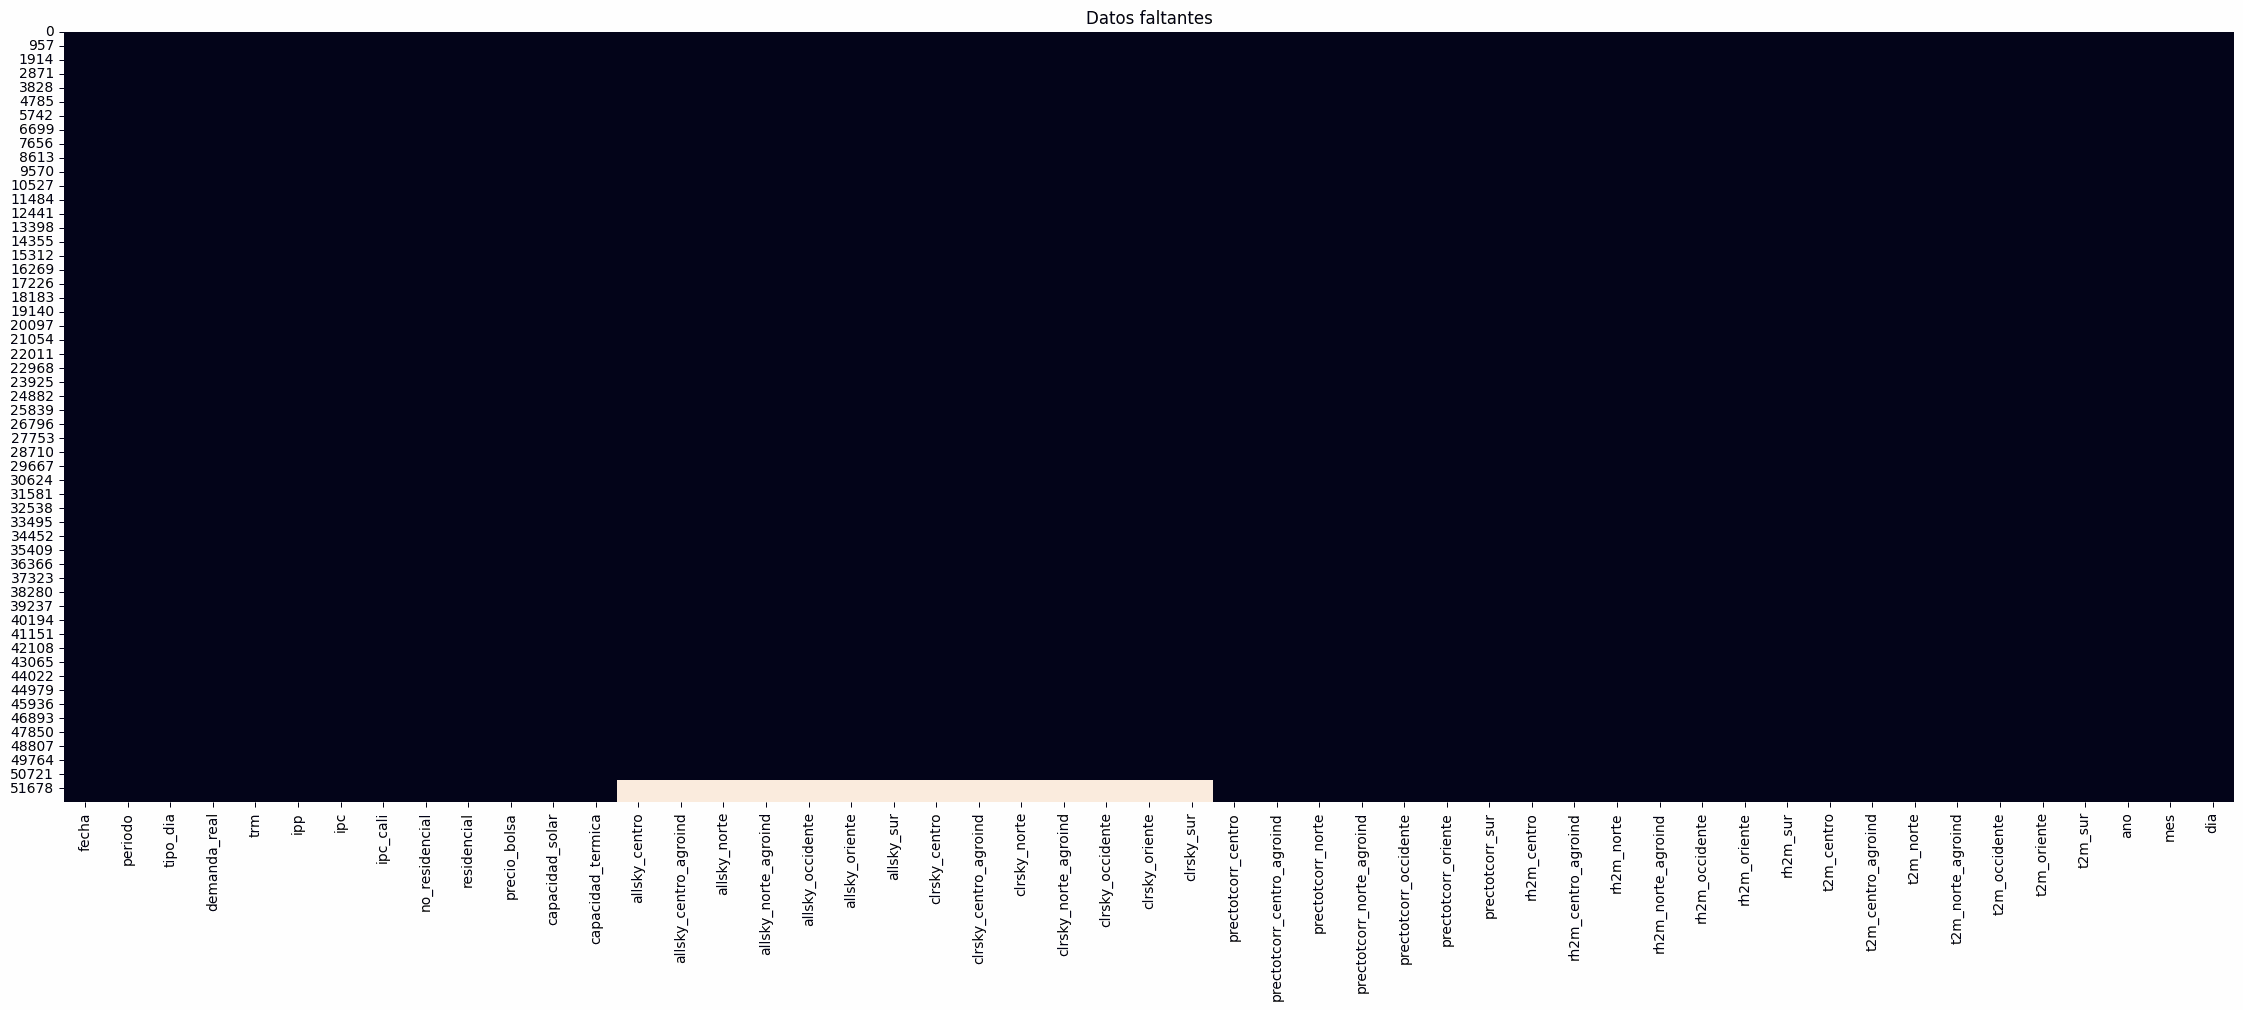

In [ ]:
# 1.6.3. Se validan los datos nulos de forma gráfica
plt.figure(figsize=(28,10))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Datos faltantes")
plt.show()

1.7. Validación de valores únicos para los campos "age" y "target"

In [ ]:
print("Valores únicos de los campos 'ano','mes','dia','tipo_dia','periodo':")
print(df["ano"].unique())
print(df["mes"].unique())
print(df["dia"].unique())
print(df["tipo_dia"].unique())
print(df["periodo"].unique())

Valores únicos de los campos 'ano','mes','dia','tipo_dia','periodo':
[2020 2021 2022 2023 2024 2025]
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
['1--ENE' '2--ENE' 'VIVENE' 'SAVENE' 'DOVENE' 'LFENE' 'MAVENE' 'MIVENE'
 'JUVENE' 'LUNES' 'MARTES' 'MIERCOLES' 'SABADO' 'DOMINGO' 'JUEVES'
 'VIERNES' 'SAALF' 'DOALF' 'LF' 'MADLF' 'MSS' 'JSS' 'VSS' 'SSS' 'DSS'
 '1--MAY' '20--JUL' '7--AGO' '8--DIC' 'SAVDIC' 'DOVDIC' 'LUVDIC' 'MAVDIC'
 'MIVDIC' '24--DIC' '25--DIC' '31--DIC' 'LUVENE' 'SAALFENE' 'DOALFENE'
 'VIVDIC' 'JUVDIC']
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]


1.8. Validación de registros duplicados en el dataset

In [ ]:
# 1.4. Se verifican los registros duplicados
print("En el dataset existen", df.duplicated().sum(), "registros o valores duplicados.")

En el dataset existen 0 registros o valores duplicados.


In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha,52608,2022-12-31 12:00:00,2020-01-01 00:00:00,2021-07-01 18:00:00,2022-12-31 12:00:00,2024-07-01 06:00:00,2025-12-31 00:00:00,NaN
periodo,52608.0,12.5,1.0,6.75,12.5,18.25,24.0,6.922252
demanda_real,52608.0,291.683063,148.34576,259.97009,290.723495,323.322648,439.06689,40.833799
trm,52608.0,4023.370228,3253.89,3790.795,3961.945,4186.4025,5061.21,347.25895
ipp,52608.0,161.415931,122.34,138.22,174.57,179.21,185.81,23.321574
ipc,52608.0,126.813203,104.24,109.14,127.15,143.67,152.27,16.9522
ipc_cali,52608.0,128.05964,105.14,111.13,129.215,144.36,152.58,16.763817
no_residencial,52608.0,30188.632755,26307.0,29046.0,29917.0,31390.0,34412.0,1787.322174
residencial,52608.0,551541.532391,489982.0,516452.0,551008.0,582494.0,617447.0,36580.293174
precio_bolsa,52608.0,348.773381,71.3358,123.974575,242.0263,456.0531,2675.6497,319.881527


1.9. Se realiza la imputación de los registros faltantes para la información faltante del dataset.

Los valores faltantes en variables climáticas fueron imputados utilizando el promedio histórico de hasta cinco años anteriores, manteniendo constante la zona geográfica, el periodo horario y el mes, con el fin de preservar la estacionalidad diaria y anual del fenómeno climático

In [ ]:
df_original = df.copy()

In [ ]:
campos_climaticos = [
    "allsky_centro", "allsky_centro_agroind", "allsky_norte",
    "allsky_norte_agroind", "allsky_occidente", "allsky_oriente",
    "allsky_sur",
    "clrsky_centro", "clrsky_centro_agroind", "clrsky_norte",
    "clrsky_norte_agroind", "clrsky_occidente", "clrsky_oriente",
    "clrsky_sur"
]
def imputar_promedio_5_anios(df, df_hist, campo):

    for ano_actual in sorted(df["ano"].unique()):

        if ano_actual <= 2020:
            continue  # no hay historia suficiente

        ventana = df_hist[
            (df_hist["ano"] >= ano_actual - 5) &
            (df_hist["ano"] < ano_actual)
        ]

        # Promedios históricos por mes y periodo
        promedios = (
            ventana
            .groupby(["mes", "periodo"])[campo]
            .mean()
        )

        mask_nan = (
            (df["ano"] == ano_actual) &
            (df[campo].isna())
        )

        for idx in df[mask_nan].index:
            mes = df.loc[idx, "mes"]
            periodo = df.loc[idx, "periodo"]

            if (mes, periodo) in promedios.index:
                df.loc[idx, campo] = promedios.loc[(mes, periodo)]

    return df

In [ ]:
for campo in campos_climaticos:
    df = imputar_promedio_5_anios(
        df=df,
        df_hist=df_original,
        campo=campo
    )

In [ ]:
# df.describe().T

In [ ]:
# df[
#     (df["ano"] == 2025) &
#     (df["mes"] == 11) &
#     (df["periodo"] == 13)
# ][["fecha", "periodo", "allsky_centro"]]

1.10. Se realizan otros metodos descriptivos en el dataframe de acuerdo a la necesidad.

In [ ]:
#df.describe()    # Muestra estadísticas descriptivas
#df.head()       # Muestra las primeras filas
#df.shape        # Muestra número de filas y columnas
#df.columns      # Muestra nombres de las columnas
# df.info()       # Muestra información del DataFrame
#df.dtypes       # Verificar tipos de variables

1.11. Se realiza un Gráfico de torta para validar la cantidad de registros por cada categoria en la variable "target" y sexo de los individuos muestreados.

1.12. Análisis descriptivo general y de acuerdo al comportamiento de target para la totalidad del dataframe

In [ ]:
#1.12.1. Se realiza el análisis descriptivo de la data
df.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha,52608,2022-12-31 12:00:00,2020-01-01 00:00:00,2021-07-01 18:00:00,2022-12-31 12:00:00,2024-07-01 06:00:00,2025-12-31 00:00:00,NaN
periodo,52608.0,12.5,1.0,6.75,12.5,18.25,24.0,6.922252
demanda_real,52608.0,291.683063,148.34576,259.97009,290.723495,323.322648,439.06689,40.833799
trm,52608.0,4023.370228,3253.89,3790.795,3961.945,4186.4025,5061.21,347.25895
ipp,52608.0,161.415931,122.34,138.22,174.57,179.21,185.81,23.321574
ipc,52608.0,126.813203,104.24,109.14,127.15,143.67,152.27,16.9522
ipc_cali,52608.0,128.05964,105.14,111.13,129.215,144.36,152.58,16.763817
no_residencial,52608.0,30188.632755,26307.0,29046.0,29917.0,31390.0,34412.0,1787.322174
residencial,52608.0,551541.532391,489982.0,516452.0,551008.0,582494.0,617447.0,36580.293174
precio_bolsa,52608.0,348.773381,71.3358,123.974575,242.0263,456.0531,2675.6497,319.881527


In [ ]:
def reporte_estadistico_por_tipo_dia(df, tipo_dia):
    reporte = []

    # Seleccionar solo variables numéricas excluyendo el target
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != tipo_dia]

    for col in numeric_cols:
        for tipo_dia_value, grupo in df.groupby(tipo_dia):

            serie = grupo[col].dropna()

            if serie.empty:
                continue

            # Estadísticos básicos
            media = serie.mean()
            mediana = serie.median()
            moda = serie.mode().iloc[0] if not serie.mode().empty else np.nan
            std = serie.std()

            # Coeficiente de variación
            cv = std / media if media != 0 else np.nan

            # Percentiles
            Q1 = serie.quantile(0.25)
            Q3 = serie.quantile(0.75)
            IQR = Q3 - Q1

            # Límites del diagrama de caja
            F1 = Q1 - 1.5 * IQR
            F3 = Q3 + 1.5 * IQR

            # Límites del diagrama de caja
            B1 = F1 - 1.5 * IQR
            B3 = F3 + 1.5 * IQR

            reporte.append({
                "tipo_dia": tipo_dia_value,
                "Variable": col,
                "Media": media,
                "Mediana": mediana,
                "Moda": moda,
                "Desviación Estándar": std,
                "Coeficiente Variación": cv,
                "Q1": Q1,
                "Q3": Q3,
                "IQR": IQR,
                "F1": F1,
                "F3": F3,
                "B1": B1,
                "B3": B3
            })

    return pd.DataFrame(reporte)

In [ ]:
reporte_df = reporte_estadistico_por_tipo_dia(df, tipo_dia="tipo_dia")
reporte_df

,tipo_dia,Variable,Media,Mediana,Moda,Desviación Estándar,Coeficiente Variación,Q1,Q3,IQR,F1,F3,B1,B3
0,1--ENE,periodo,12.500000,12.5,1.0,6.946348,0.555708,6.75,18.25,11.5,-10.5,35.5,-27.75,52.75
1,1--MAY,periodo,12.500000,12.5,1.0,6.946348,0.555708,6.75,18.25,11.5,-10.5,35.5,-27.75,52.75
2,2--ENE,periodo,12.500000,12.5,1.0,6.946348,0.555708,6.75,18.25,11.5,-10.5,35.5,-27.75,52.75
3,20--JUL,periodo,12.500000,12.5,1.0,6.946348,0.555708,6.75,18.25,11.5,-10.5,35.5,-27.75,52.75
4,24--DIC,periodo,12.500000,12.5,1.0,6.946348,0.555708,6.75,18.25,11.5,-10.5,35.5,-27.75,52.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,SSS,dia,14.500000,13.5,3.0,8.685653,0.599011,8.00,19.00,11.0,-8.5,35.5,-25.00,52.00
2054,VIERNES,dia,15.888489,16.0,21.0,8.748429,0.550614,8.00,24.00,16.0,-16.0,48.0,-40.00,72.00
2055,VIVDIC,dia,23.666667,23.0,17.0,4.330530,0.182980,20.00,27.00,7.0,9.5,37.5,-1.00,48.00
2056,VIVENE,dia,9.461538,10.0,3.0,4.403133,0.465372,6.00,13.00,7.0,-4.5,23.5,-15.00,34.00


1.13. Análisis de registros atípicos y extremadamente atípicos

In [ ]:
variables_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [ ]:
def eliminar_extremos_detallado(variables):

    reporte = []
    indices_eliminar = set()

    for col in variables:

        # Cuartiles
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Bigotes IQR clásicos
        B1 = Q1 - 1.5 * IQR
        B3 = Q3 + 1.5 * IQR

        # Fronteras para valores EXTREMOS
        F1 = B1 - 1.5 * IQR
        F3 = B3 + 1.5 * IQR

        mask = (df[col] < F1) | (df[col] > F3)
        outliers_idx = df[mask].index

        indices_eliminar.update(outliers_idx)

    # Eliminación consolidada
    df_limpio = df.drop(index=list(indices_eliminar)).reset_index(drop=True)

    print(f"TOTAL registros eliminados en toda la limpieza: {len(indices_eliminar)}")

    reporte_df = pd.DataFrame(reporte)

    return df_limpio

In [ ]:
df_limpio = eliminar_extremos_detallado(variables_numericas)

TOTAL registros eliminados en toda la limpieza: 8122


In [ ]:
df_limpio.shape

(44486, 51)

In [ ]:
df.shape

(52608, 51)

In [ ]:
df_limpio.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha,44486,2022-12-10 03:59:01.087083520,2020-01-01 00:00:00,2021-06-10 00:00:00,2022-12-03 00:00:00,2024-06-02 00:00:00,2025-12-31 00:00:00,NaN
periodo,44486.0,12.59857,1.0,7.0,13.0,18.0,24.0,6.843525
demanda_real,44486.0,293.028639,148.34576,260.958145,292.78682,324.6608,439.06689,40.947313
trm,44486.0,4013.043132,3253.89,3785.7,3948.7,4172.13,5061.21,346.206334
ipp,44486.0,160.524621,122.34,136.95,174.46,179.21,185.81,23.551426
ipc,44486.0,126.228929,104.24,108.84,126.03,143.38,152.27,17.01258
ipc_cali,44486.0,127.476442,105.14,110.67,128.07,144.04,152.58,16.835545
no_residencial,44486.0,30122.240255,26307.0,29003.0,29917.0,31123.0,34412.0,1797.029869
residencial,44486.0,550103.500067,489982.0,516281.0,550003.0,579727.0,617447.0,36741.277261
precio_bolsa,44486.0,330.918262,71.3358,124.655925,242.845,452.6683,1451.8988,259.17228


In [ ]:
def unificar_variables_climaticas(
    df,
    variables_base=("allsky", "clrsky", "t2m", "rh2m", "prectotcorr"),
    zonas=(
        "centro",
        "centro_agroind",
        "norte",
        "norte_agroind",
        "occidente",
        "oriente",
        "sur",
    ),
    metodo="mean"
):
    """
    Unifica variables climáticas por fecha exacta (año, mes, día, periodo)
    agregando la información de las distintas zonas.

    Parámetros
    ----------
    df : DataFrame
        Dataset original
    variables_base : tuple
        Variables climáticas base (ej. allsky, t2m, etc.)
    zonas : tuple
        Zonas consideradas
    metodo : str
        Método de agregación: 'mean' o 'median'

    Retorna
    -------
    DataFrame con nuevas variables climáticas unificadas
    """

    df = df.copy()

    for var in variables_base:
        columnas = [f"{var}_{zona}" for zona in zonas if f"{var}_{zona}" in df.columns]

        if not columnas:
            print(f"⚠️ No se encontraron columnas para {var}")
            continue

        if metodo == "mean":
            df[var] = df[columnas].mean(axis=1, skipna=True)
        elif metodo == "median":
            df[var] = df[columnas].median(axis=1, skipna=True)
        else:
            raise ValueError("El método debe ser 'mean' o 'median'")

    return df

In [ ]:
df_clima_unificado = unificar_variables_climaticas(df)

In [ ]:
df_clima_unificado[
    ["fecha", "periodo", "allsky", "clrsky", "t2m", "rh2m", "prectotcorr"]
].head(60)

,fecha,periodo,allsky,clrsky,t2m,rh2m,prectotcorr
0,2020-01-01,1,0.000000,0.000000,18.027143,99.430000,2.272857
1,2020-01-01,2,0.000000,0.000000,17.904286,99.422857,2.364286
2,2020-01-01,3,0.000000,0.000000,17.760000,99.432857,2.554286
3,2020-01-01,4,0.000000,0.000000,17.628571,99.382857,2.587143
4,2020-01-01,5,0.000000,0.000000,17.524286,99.240000,2.418571
5,2020-01-01,6,0.000000,0.000000,17.454286,99.062857,2.212857
6,2020-01-01,7,22.542857,34.678571,17.695714,98.627143,2.042857
7,2020-01-01,8,160.074286,250.282857,18.742857,95.784286,2.147143
8,2020-01-01,9,329.434286,493.744286,19.742857,91.095714,2.377143
9,2020-01-01,10,488.821429,704.038571,21.084286,82.957143,2.811429


In [ ]:
def eliminar_variables_climaticas_por_zona(
    df,
    variables_base=("allsky", "clrsky", "t2m", "rh2m", "prectotcorr"),
    zonas=(
        "centro",
        "centro_agroind",
        "norte",
        "norte_agroind",
        "occidente",
        "oriente",
        "sur",
    )
):
    """
    Elimina las columnas climáticas desagregadas por zona,
    conservando únicamente las variables climáticas unificadas.
    """

    df = df.copy()

    columnas_a_eliminar = []

    for var in variables_base:
        for zona in zonas:
            col = f"{var}_{zona}"
            if col in df.columns:
                columnas_a_eliminar.append(col)

    df.drop(columns=columnas_a_eliminar, inplace=True)

    return df

In [ ]:
df_pronostico_final = eliminar_variables_climaticas_por_zona(df_clima_unificado)

In [ ]:
df_pronostico_final.shape


(52608, 21)

In [ ]:
variables_numericas = df_pronostico_final.drop(['fecha','tipo_dia','periodo','ano','mes','dia','capacidad_solar','capacidad_termica'], axis=1)

In [ ]:
variables_numericas.columns

Index(['demanda_real', 'trm', 'ipp', 'ipc', 'ipc_cali', 'no_residencial',
       'residencial', 'precio_bolsa', 'allsky', 'clrsky', 't2m', 'rh2m',
       'prectotcorr'],
      dtype='object')

In [ ]:
df_pronostico_final["tipo_dia"].unique()

array(['1--ENE', '2--ENE', 'VIVENE', 'SAVENE', 'DOVENE', 'LFENE',
       'MAVENE', 'MIVENE', 'JUVENE', 'LUNES', 'MARTES', 'MIERCOLES',
       'SABADO', 'DOMINGO', 'JUEVES', 'VIERNES', 'SAALF', 'DOALF', 'LF',
       'MADLF', 'MSS', 'JSS', 'VSS', 'SSS', 'DSS', '1--MAY', '20--JUL',
       '7--AGO', '8--DIC', 'SAVDIC', 'DOVDIC', 'LUVDIC', 'MAVDIC',
       'MIVDIC', '24--DIC', '25--DIC', '31--DIC', 'LUVENE', 'SAALFENE',
       'DOALFENE', 'VIVDIC', 'JUVDIC'], dtype=object)

# **2. ANÁLISIS DIAGNÓSTICO**

Ahora se decide hacer varios gráficos que ayuden a mostrar con mejor detalle como es la distribución de las distintas variables para la población muestreada, esto se hace por medio del gráfico del Histograma, el histograma de acuerdo al campo 'tipo_dia'.

2.1. Análisis por medio del gráfico del Histograma

2.1.1. Histograma general para variables cuantitativas

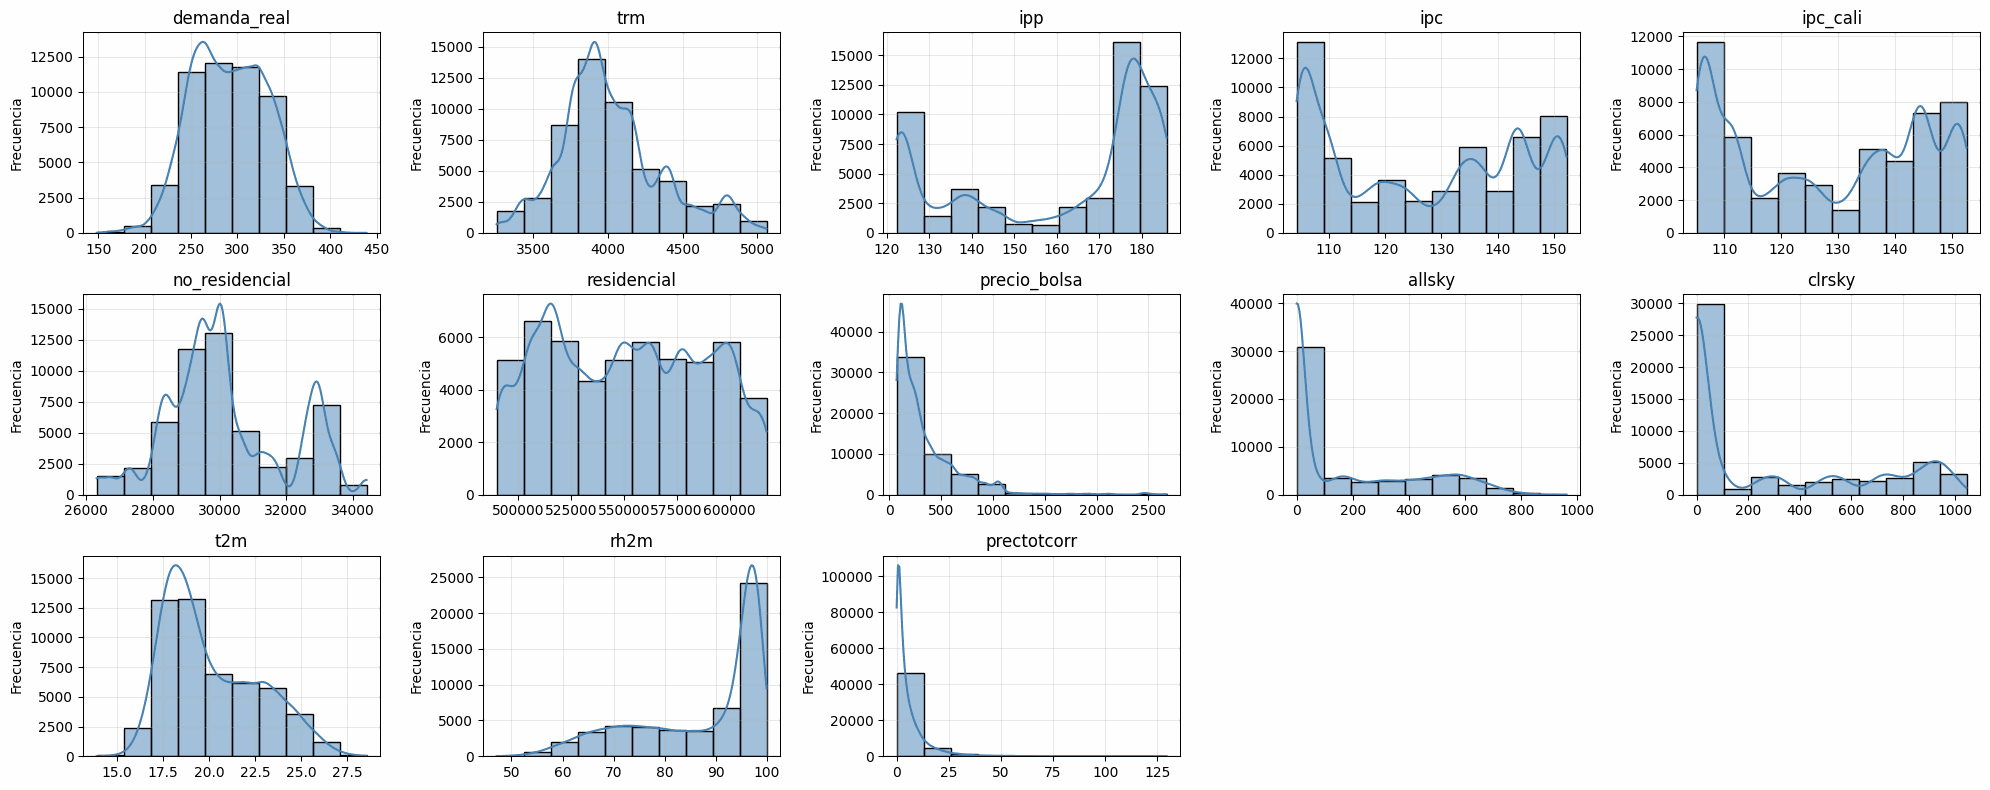

In [ ]:
# Histograma de las variables predictoras
num_cols = 5  # número de columnas
num_rows = 3  # número de filas

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 8))
axes = axes.flatten()  # convertir en una lista plana

for i, col in enumerate(variables_numericas[:num_rows * num_cols]):  # hasta 5 variables
    sns.histplot(df_pronostico_final[col], ax=axes[i], kde=True, color="steelblue", bins=10)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(alpha=0.3)

# Elimina los ejes sobrantes si hay menos de 5 variables
for j in range(i + 1, num_rows * num_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

2.1.2. Histograma de acuerdo con el 'tipo_dia'

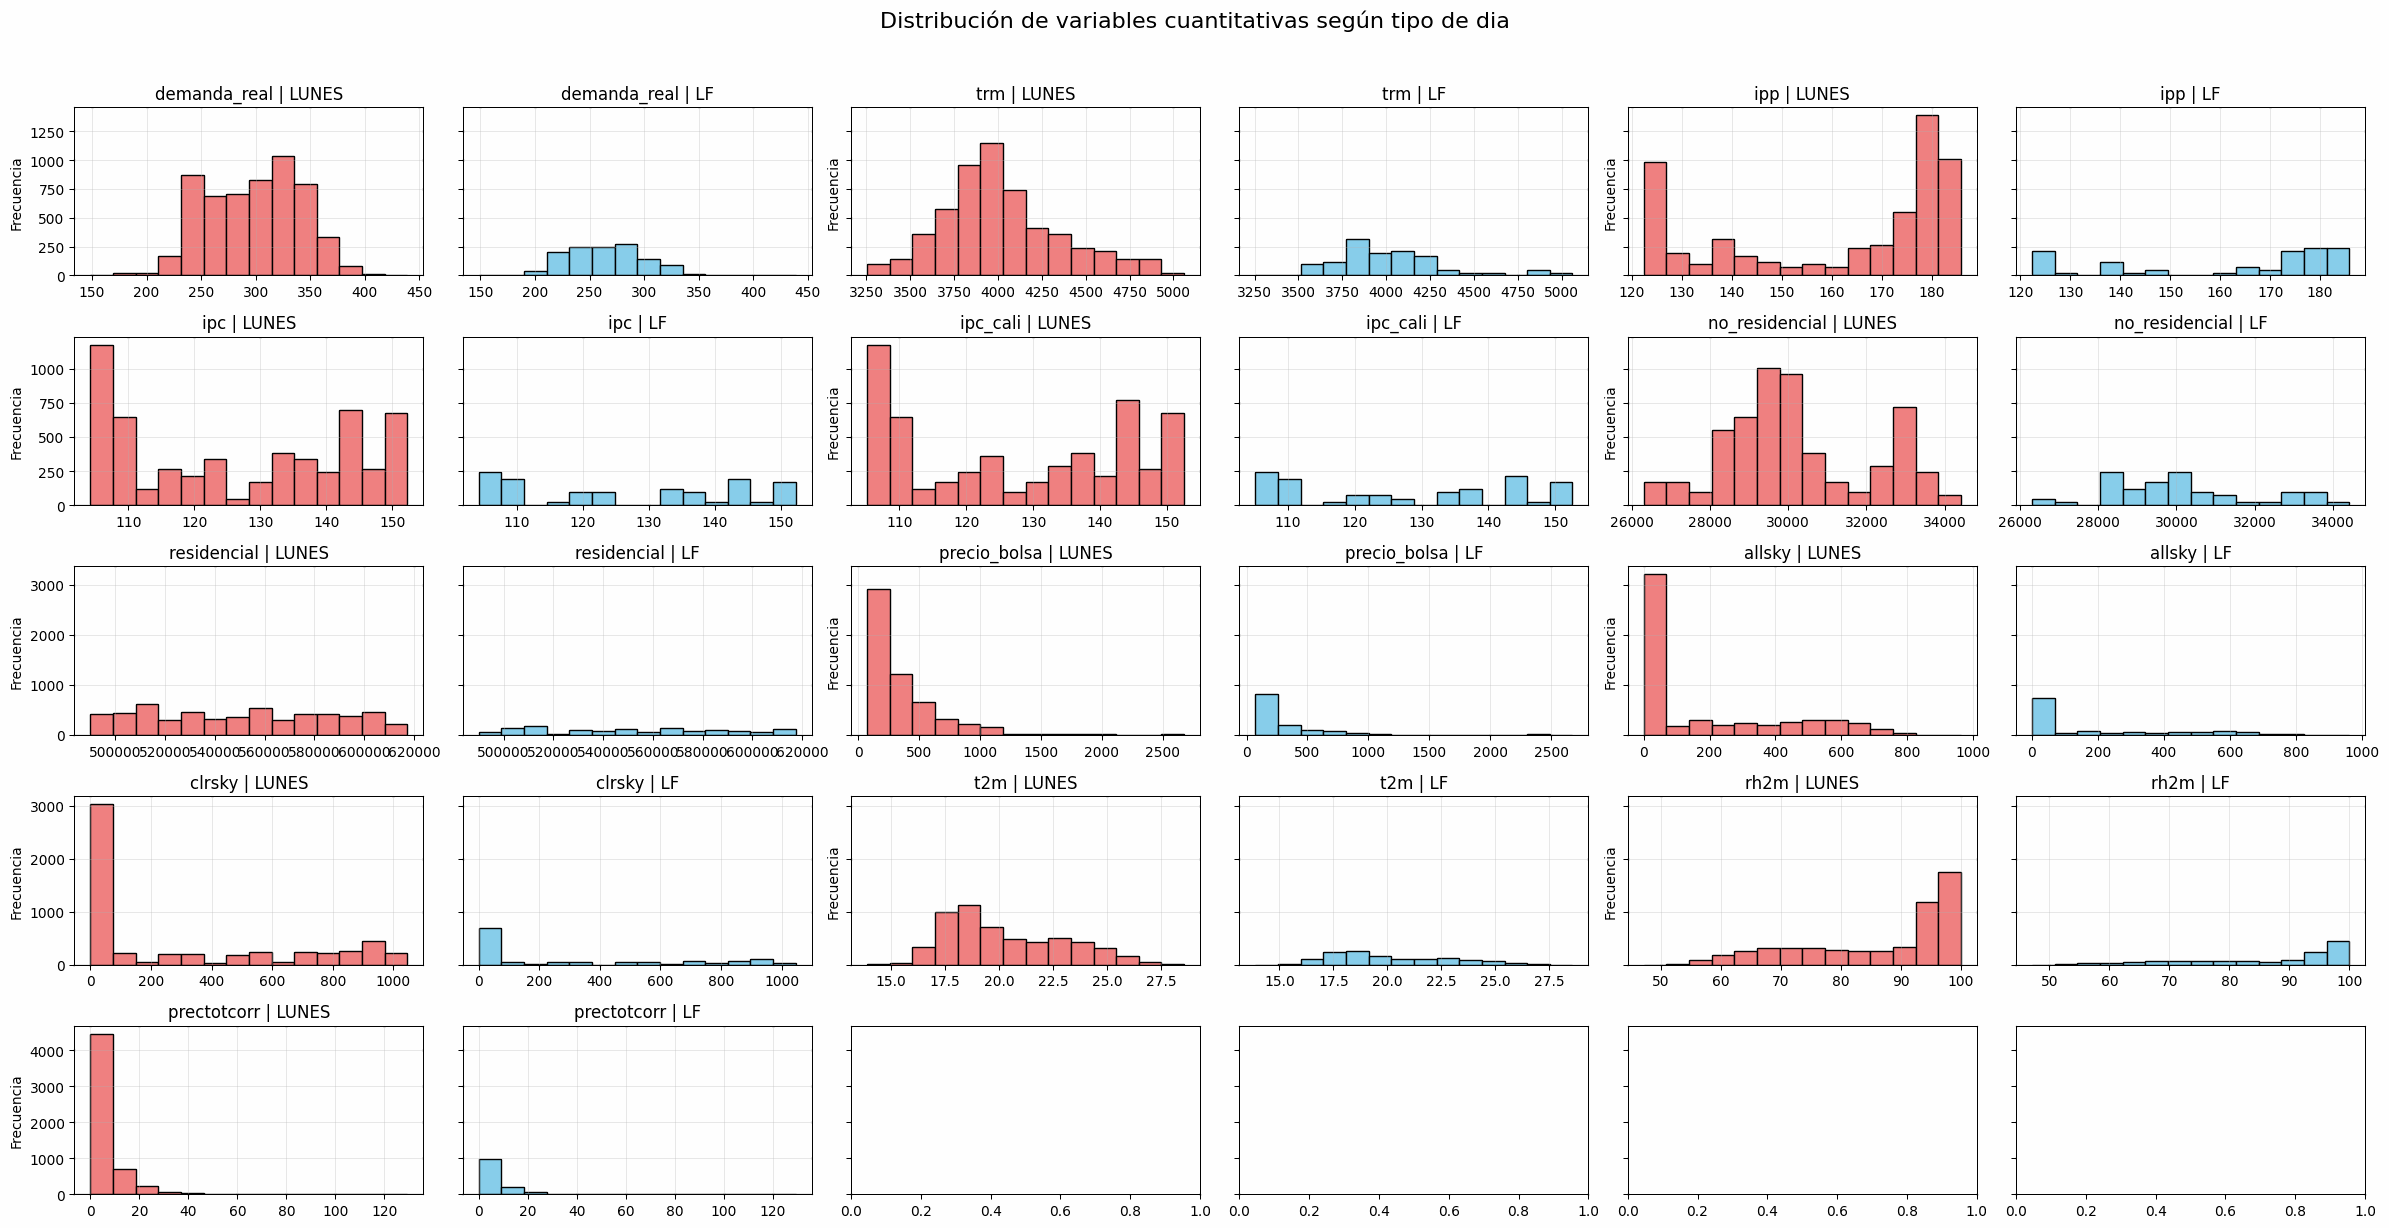

In [ ]:
n_rows = 5
n_cols = 6

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 12), sharey="row")

for idx, var in enumerate(variables_numericas):

    row = idx // 3
    col_start = (idx % 3) * 2  # cada variable ocupa 2 columnas

    # Bins comunes por variable
    min_val = df_pronostico_final[var].min()
    max_val = df_pronostico_final[var].max()
    bins = np.linspace(min_val, max_val, 15)

    # --- LUNES ---
    axes[row, col_start].hist(
        df_pronostico_final[df_pronostico_final["tipo_dia"] == 'LUNES'][var],
        bins=bins, color="lightcoral", edgecolor="black"
    )
    axes[row, col_start].set_title(f"{var} | LUNES")

    # --- LUNES FESTIVO---
    axes[row, col_start + 1].hist(
        df_pronostico_final[df_pronostico_final["tipo_dia"] == 'LF'][var],
        bins=bins, color="skyblue", edgecolor="black"
    )
    axes[row, col_start + 1].set_title(f"{var} | LF")

    for c in [col_start, col_start + 1]:
        axes[row, c].grid(alpha=0.3)
        axes[row, c].set_xlabel("")

    axes[row, col_start].set_ylabel("Frecuencia")

plt.suptitle(
    "Distribución de variables cuantitativas según tipo de dia",
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

2.2.1. Gráfico de caja para las variables cuantitativas


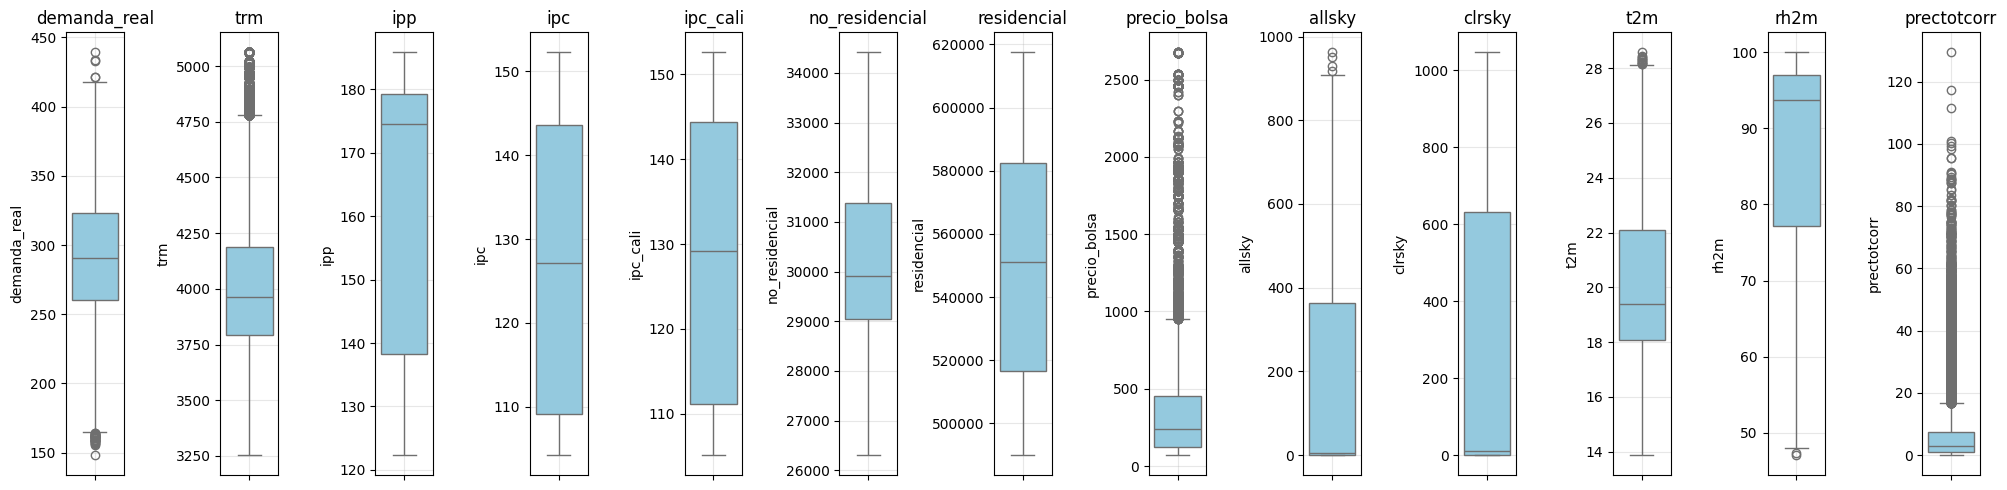

In [ ]:
n_rows = 1
n_cols = 13

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5))

for i, col in enumerate(variables_numericas):
    sns.boxplot(y=df_pronostico_final[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

2.2.2. Gráfico de caja de acuerdo al 'tipo_dia'

In [ ]:
# @title
# n_rows = 2
# n_cols = 6

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 12))

# for idx, var in enumerate(variables_numericas):

#     row = idx // 3
#     col_start = (idx % 3) * 2

#     # 🔹 Escala robusta por percentiles (5% – 95%)
#     q_low, q_high = np.percentile(df_pronostico_final[var].dropna(), [0, 100])

#     # Outcome = 0
#     sns.boxplot(
#         y=df_pronostico_final[df_pronostico_final["target"] == 0][var],
#         ax=axes[row, col_start],
#         color="lightcoral"
#     )
#     axes[row, col_start].set_title(f"{var} | target = 0")
#     axes[row, col_start].set_ylim(q_low, q_high)
#     axes[row, col_start].grid(alpha=0.3)

#     # Outcome = 1
#     sns.boxplot(
#         y=df_pronostico_final[df_pronostico_final["target"] == 1][var],
#         ax=axes[row, col_start + 1],
#         color="skyblue"
#     )
#     axes[row, col_start + 1].set_title(f"{var} | target = 1")
#     axes[row, col_start + 1].set_ylim(q_low, q_high)
#     axes[row, col_start + 1].grid(alpha=0.3)

#     # Etiqueta Y solo una vez por variable
#     axes[row, col_start].set_ylabel("Valor")

# plt.suptitle(
#     "Diagramas de caja de variables predictoras según target (escala ajustada por percentiles)",
#     fontsize=16, y=1.02
# )

# plt.tight_layout()
# plt.show()

2.3. Verificación a través de la correlación (pearson, spearman y kendall) entre variables.

Se comprueban las correlaciones antes de realizar el escalamiento de los Outliers las correlaciones lineales existentes entre las variables predictivas, ya que esto puede afectar negativamente si estás se encuentran correlacionadas entre sí (redundancia).

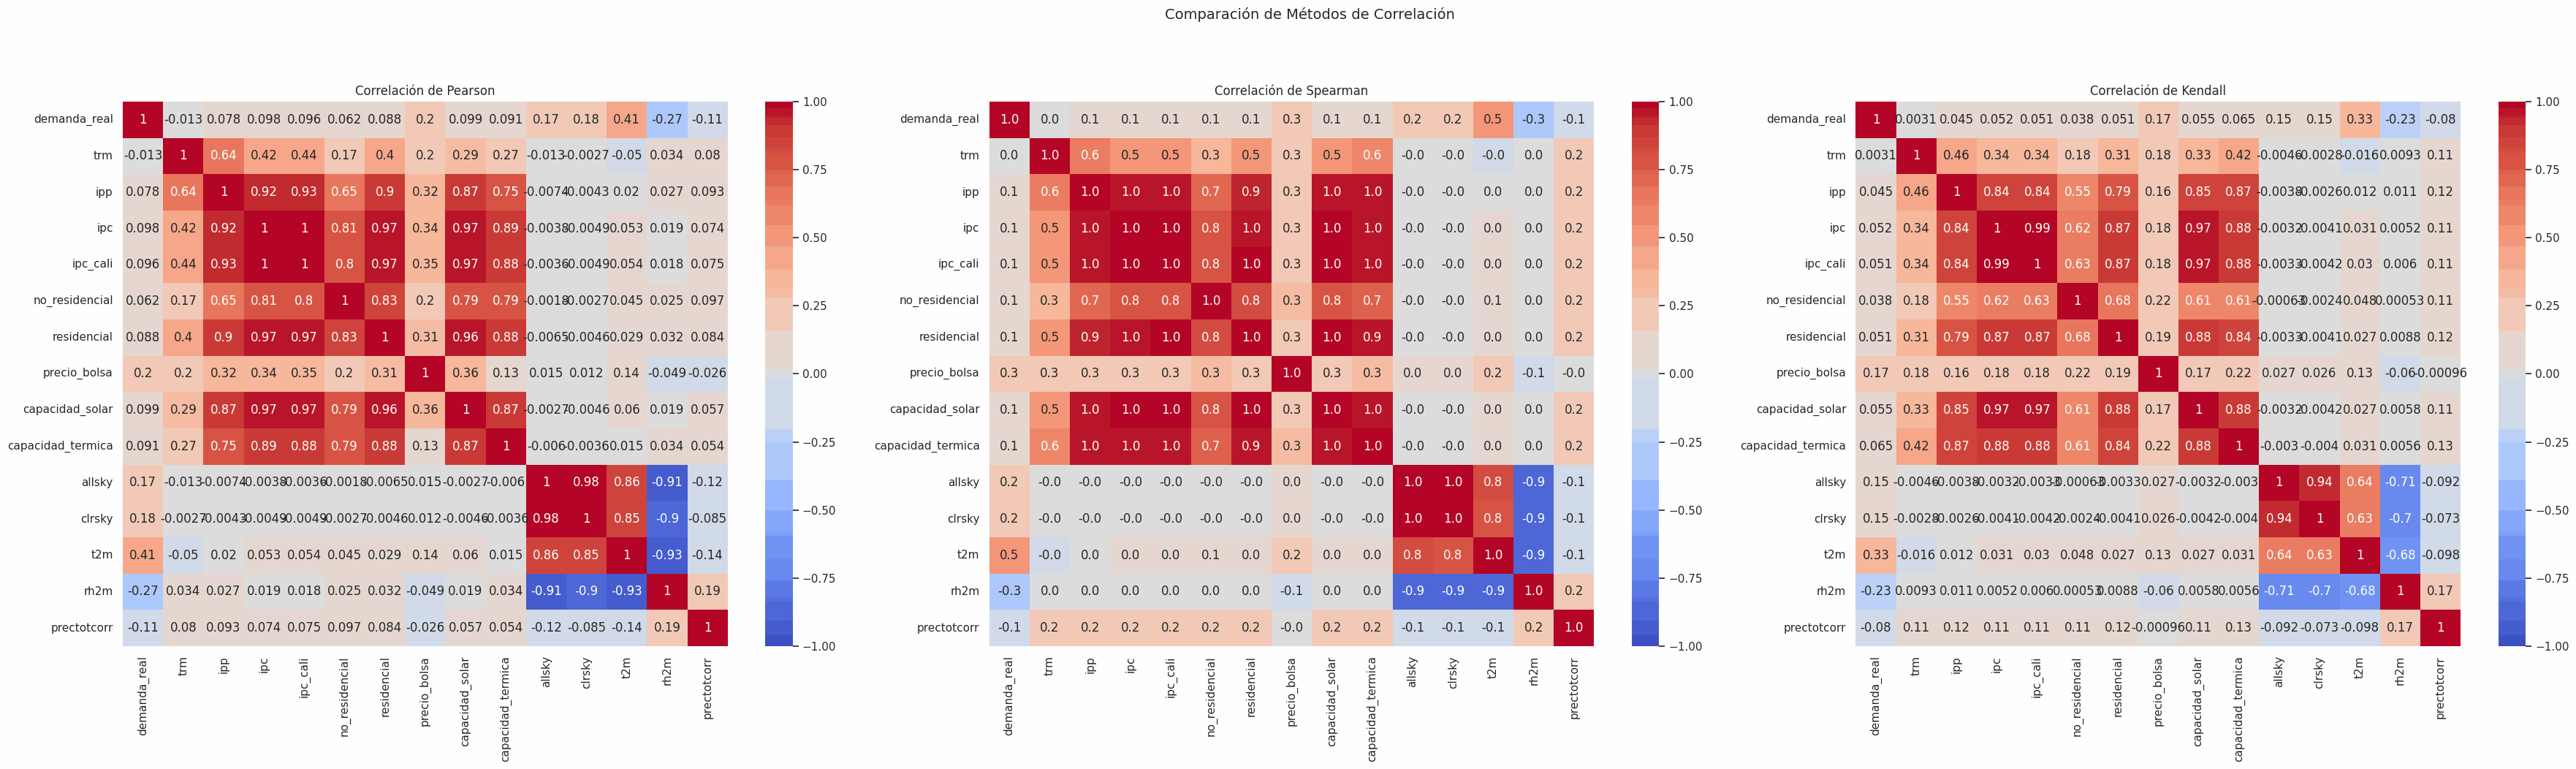

In [ ]:
df_pronostico_final2 = df_pronostico_final.drop(['fecha','tipo_dia','periodo','ano','mes','dia'], axis=1)

# --- Cálculo de las tres matrices ---
corr_pearson = df_pronostico_final2.corr(method="pearson")
corr_spearman = df_pronostico_final2.corr(method="spearman")
corr_kendall = df_pronostico_final2.corr(method="kendall")

# --- Estilo visual ---
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.8", "grid.alpha": 0.3})

# --- Crear figura con 3 columnas ---
fig, axes = plt.subplots(1, 3, figsize=(36, 10))

# --- Pearson ---
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlación de Pearson", fontsize=12)

# --- Spearman ---
sns.heatmap(corr_spearman, annot=True, fmt=".1f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlación de Spearman", fontsize=12)

# --- Kendall ---
sns.heatmap(corr_kendall, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Correlación de Kendall", fontsize=12)

# --- Título general y ajustes ---
plt.suptitle("Comparación de Métodos de Correlación", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# **3. ANÁLISIS PREDICTIVO**

# **Particionamiento del segmento de entrenamiento (train) y prueba (test)**

In [ ]:
df_pronostico_final

,fecha,periodo,tipo_dia,demanda_real,trm,ipp,ipc,ipc_cali,no_residencial,residencial,...,capacidad_solar,capacidad_termica,ano,mes,dia,allsky,clrsky,t2m,rh2m,prectotcorr
0,2020-01-01,1,1--ENE,239.95562,3277.14,122.34,104.24,105.14,29579,494874,...,9913.64,82900,2020,1,1,0.0,0.0,18.027143,99.430000,2.272857
1,2020-01-01,2,1--ENE,230.08609,3277.14,122.34,104.24,105.14,29579,494874,...,9913.64,82900,2020,1,1,0.0,0.0,17.904286,99.422857,2.364286
2,2020-01-01,3,1--ENE,220.81891,3277.14,122.34,104.24,105.14,29579,494874,...,9913.64,82900,2020,1,1,0.0,0.0,17.760000,99.432857,2.554286
3,2020-01-01,4,1--ENE,214.77489,3277.14,122.34,104.24,105.14,29579,494874,...,9913.64,82900,2020,1,1,0.0,0.0,17.628571,99.382857,2.587143
4,2020-01-01,5,1--ENE,209.83059,3277.14,122.34,104.24,105.14,29579,494874,...,9913.64,82900,2020,1,1,0.0,0.0,17.524286,99.240000,2.418571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,2025-12-31,20,31--DIC,342.40726,3757.08,181.10,152.27,152.58,31574,617447,...,108494.17,102290,2025,12,31,0.0,0.0,20.028571,95.082857,2.565714
52604,2025-12-31,21,31--DIC,331.80096,3757.08,181.10,152.27,152.58,31574,617447,...,108494.17,102290,2025,12,31,0.0,0.0,19.784286,95.734286,2.328571
52605,2025-12-31,22,31--DIC,317.10690,3757.08,181.10,152.27,152.58,31574,617447,...,108494.17,102290,2025,12,31,0.0,0.0,19.577143,96.008571,1.928571
52606,2025-12-31,23,31--DIC,308.10374,3757.08,181.10,152.27,152.58,31574,617447,...,108494.17,102290,2025,12,31,0.0,0.0,19.357143,96.238571,1.672857


Asegurar tipos y ordenar

In [ ]:
df = df_pronostico_final.copy()

cols_tiempo = ["ano", "mes", "dia", "periodo"]
cols_clima = ["allsky", "clrsky", "t2m", "rh2m", "prectotcorr"]

df[cols_tiempo] = df[cols_tiempo].astype(int)
df = df.sort_values(["ano", "mes", "dia", "periodo"]).reset_index(drop=True)

In [ ]:
# ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Exportación dataset
root.mkdir(parents=True, exist_ok=True)

ruta_salida = root / 'df_dataset_demanda_valle_depurado.xlsx'
df_pronostico_final.to_excel(ruta_salida, index=False)

Crear índice datetime (clave para SARIMAX)

In [ ]:
df["fecha"] = pd.to_datetime(
    dict(
        year=df["ano"],
        month=df["mes"],
        day=df["dia"]
    )
) + pd.to_timedelta(df["periodo"], unit="h")

df = df.set_index("fecha")

In [ ]:
# Mes (estacionalidad anual)
days_in_year = df.index.is_leap_year.map({True: 366, False: 365})
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / days_in_year)
df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / days_in_year)

# Mes (estacionalidad anual)
df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)


# Periodo (estacionalidad diaria)
df["periodo_sin"] = np.sin(2 * np.pi * df["periodo"] / 24)
df["periodo_cos"] = np.cos(2 * np.pi * df["periodo"] / 24)

AttributeError: 'numpy.ndarray' object has no attribute 'map'

# **Dataset SARIMAX**
No incluye variables temporales como features

In [ ]:
df_sarimax = df[cols_clima].copy()

Validación de estacionariedad
¿Para qué sirven las pruebas de estacionariedad ADF y KPSS?

Estas pruebas permiten determinar si una serie de tiempo es estacionaria, es decir, si sus propiedades estadísticas (media, varianza) se mantienen constantes a lo largo del tiempo. La estacionariedad es fundamental para aplicar modelos clásicos de pronóstico como ARIMA/SARIMA, ya que estos modelos asumen que la serie no tiene tendencias ni cambios estructurales. Si la serie no es estacionaria, se deben aplicar transformaciones (como la diferenciación) antes de modelar. Las pruebas de estacionariedad son el primer paso para validar si podemos aplicar modelos de pronóstico confiables. Si la serie es estacionaria, avanzamos; si no, la transformamos y volvemos a probar.

In [ ]:
# Validación de estacionariedad
result_adf = adfuller(df_train['Valor'])
print('ADF Statistic:', result_adf[0])
print('p-value:', result_adf[1])
if result_adf[1] < 0.05:
    print('La serie es estacionaria según ADF.')
else:
    print('La serie NO es estacionaria según ADF.')
print("*****************")
result_kpss = kpss(df_train['Valor'], regression='c')
print('KPSS Statistic:', result_kpss[0])
print('p-value:', result_kpss[1])
if result_kpss[1] < 0.05:
    print('La serie NO es estacionaria según KPSS.')
else:
    print('La serie es estacionaria según KPSS.')

# **Dataset RLM (regresión robusta)**

In [ ]:
features_rlm = (
    cols_clima +
    ["ano", "dia", "mes_sin", "mes_cos", "periodo_sin", "periodo_cos"]
)

df_rlm = df[features_rlm].copy()

# **Dataset SVM (requiere escalado)**

In [ ]:
features_svm = (cols_clima + ["mes_sin", "mes_cos", "periodo_sin", "periodo_cos"])

scaler_svm = StandardScaler()
df_svm = pd.DataFrame(
    scaler_svm.fit_transform(df[features_svm]),
    columns=features_svm,
    index=df.index
)

# **Dataset Random Forest Regressor**

In [ ]:
features_rfr = (cols_clima + ["mes", "periodo", "mes_sin", "mes_cos", "periodo_sin", "periodo_cos"])

df_rfr = df[features_rfr].copy()

# **Dataset para RNN / GRU / LSTM**

In [ ]:
features_dl = (
    cols_clima +
    ["mes_sin", "mes_cos", "periodo_sin", "periodo_cos"]
)

scaler_dl = StandardScaler()

df_dl = pd.DataFrame(
    scaler_dl.fit_transform(df[features_dl]),
    columns=features_dl,
    index=df.index
)

In [ ]:
import joblib

joblib.dump(scaler_svm, "scaler_svm.joblib")
joblib.dump(scaler_dl, "scaler_dl.joblib")

df_sarimax.to_parquet("df_sarimax.parquet")
df_rlm.to_parquet("df_rlm.parquet")
df_svm.to_parquet("df_svm.parquet")
df_rfr.to_parquet("df_rfr.parquet")
df_dl.to_parquet("df_dl.parquet")